In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'


,elbo_train,reconstruction_loss_train,kl_local_train,elbo_validation,reconstruction_loss_validation,kl_local_validation,reconstruction_val_dff,kl_val_dff
epoch,,,,,,,,
7.0,4136.131836,4014.785889,121.346153,4106.192871,3990.848389,115.344696,-1.388672,-5.266724
8.0,4131.354004,4013.614990,117.738907,4102.969727,3989.664062,113.305565,-1.184326,-2.039131
9.0,4127.196289,4012.630127,114.566299,4098.839844,3989.123535,109.716309,-0.540527,-3.589256
10.0,4123.414551,4011.830811,111.583824,4095.846436,3988.328125,107.518311,-0.795410,-2.197998
11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


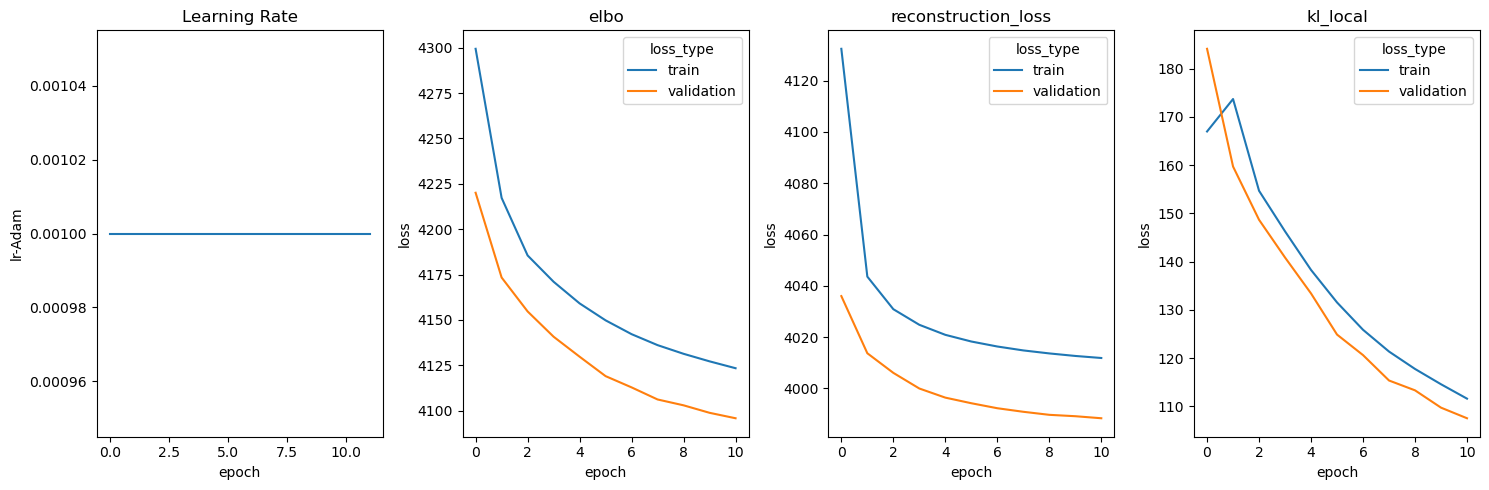

In [62]:
metrics_path = os.path.join(
    data_path, 'interim',
    author + '_scvi_mod',
    'overwrite_2', # overwrite
    'metrics.csv'
)

df = pd.read_csv(metrics_path)
fig, ax = plt.subplots(ncols = 4, figsize = (15, 5))


loss_cols = ['elbo', 'reconstruction_loss']#, 'kl_local']

i = 0
viz_df = df[df['lr-Adam'].notna()][['epoch', 'lr-Adam']]
viz_df.epoch = range(viz_df.shape[0])
sns.lineplot(viz_df, x = 'epoch', y = 'lr-Adam', ax = ax[i])
ax[i].set_title('Learning Rate')


df = df.groupby('epoch').mean()
for i_, loss_type in enumerate(['elbo', 'reconstruction_loss', 'kl_local']):
    i = i+1
    viz_df = df[[loss_type + '_train', loss_type + '_validation']].copy().reset_index()
    viz_df = pd.melt(viz_df, id_vars = 'epoch', var_name = 'loss_type', value_name = 'loss')
    viz_df.loss_type = viz_df.loss_type.apply(lambda x: x.split('_')[-1])
    sns.lineplot(viz_df, x = 'epoch', y = 'loss', hue = 'loss_type', ax = ax[i])
    ax[i].set_title(loss_type)

fig.tight_layout();

loss_cols = ['elbo', 'reconstruction_loss', 'kl_local']
df['reconstruction_val_dff'] = df.reconstruction_loss_validation.diff()
df['kl_val_dff'] = df.kl_local_validation.diff()
new_cols = ['reconstruction_val_dff', 'kl_val_dff']
df[[col + '_train' for col in loss_cols] + [col + '_validation' for col in loss_cols] + new_cols].tail()

In [24]:
# import time
# import os

# import numpy as np
# import pandas as pd

# from scipy import stats
# from sklearn.decomposition import PCA

# import scanpy as sc

# import matplotlib.pyplot as plt
# import seaborn as sns

# import sys
# sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
# sys.path.insert(1, os.path.join(sclembas_path))
# from scLEMBAS import io
# from scLEMBAS import preprocess as pp
# import scLEMBAS.utilities as utils



# import scvi
# from scipy import sparse
# # from lightning.pytorch.strategies import DDPStrategy

# n_cores = 80
# os.environ["OMP_NUM_THREADS"] = str(n_cores)
# os.environ["MKL_NUM_THREADS"] = str(n_cores)
# os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
# os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
# os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

# data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
# author = 'Tahoe100M'
# seed = 888

# scvi.settings.seed = seed
# scvi._settings.ScviConfig.dl_num_workers = n_cores


# # scvi requires raw counts
# adata = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_normalized_counts.h5ad'))
# adata_raw = sc.read_h5ad(os.path.join(data_path, 'interim', author + '_filtered_counts.h5ad'))
# adata.layers['counts'] = adata_raw.X.copy()

# # fraction of cells to keep
# n = 0.01

# # randomly choose indices
# np.random.seed(seed)
# subset_idx = np.random.choice(
#     adata.n_obs,                # total number of cells
#     size=int(n * adata.n_obs),  # number to sample
#     replace=False               # no duplicates
# )

# # subset AnnData
# adata = adata[subset_idx].copy()

# scvi.model.SCVI.setup_anndata(
#     adata,
#     layer = 'counts', 
#     #strategy=DDPStrategy(find_unused_parameters=True),
#     categorical_covariate_keys=['plate'],
#     continuous_covariate_keys=['pcnt_mito'],
# )
# scvi_mod = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

# n_gpus = 1

# # scvi_mod.train(
# #     max_epochs = 2, 
# #     check_val_every_n_epoch = 1,
# #     simple_progress_bar=True,
# #     enable_progress_bar = True, 
# #     accelerator = 'gpu', 
# #     devices = 1,  
# #     early_stopping = True, 
# #     early_stopping_patience = 30, 
# #     batch_size = 4098, 
# #     plan_kwargs={'lr': 1e-3,         
# #                  'reduce_lr_on_plateau': True,
# #                  'lr_patience': 8,
# #                  'lr_factor': 0.6}, 
# # )

[rank: 0] Seed set to 888
